In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

d = pd.read_csv('data PM10 mean 2025.csv', sep=";")

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

print(d_metro["nom site"].nunique())

297


# Comparaison

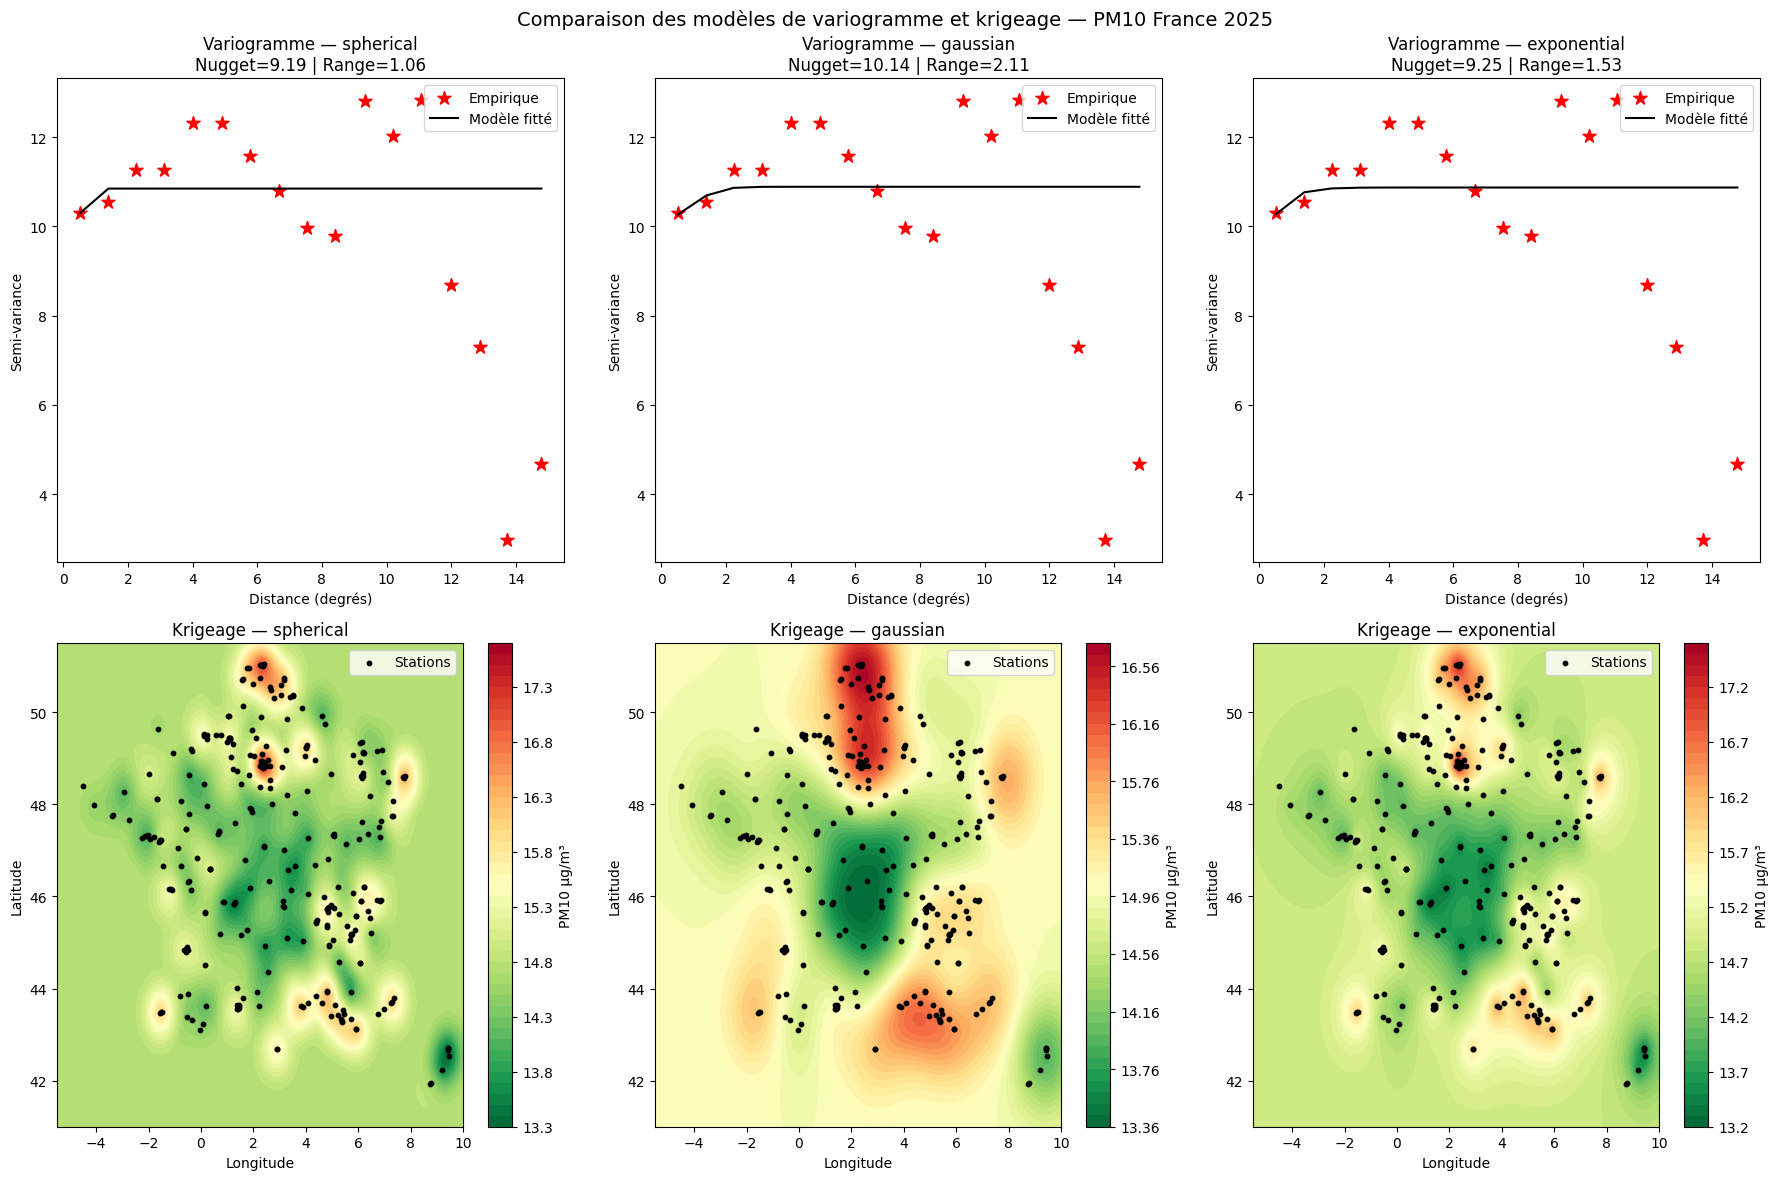

In [17]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        nlags=17,
        verbose=False,
        enable_plotting=False
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()

## Validation croisée

In [15]:
modeles = ["spherical", "gaussian", "exponential"]

for modele in modeles:
    predicted = []
    for i in range(len(lons)):
        lons_cv = np.delete(lons, i)
        lats_cv = np.delete(lats, i)
        vals_cv = np.delete(vals, i)
        OK_cv = OrdinaryKriging(
            lons_cv, lats_cv, vals_cv,
            variogram_model=modele,
            nlags=19,
            verbose=False,
            enable_plotting=False
        )
        z, _ = OK_cv.execute("points", [lons[i]], [lats[i]])
        predicted.append(z[0])
    
    rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
    mae = np.mean(np.abs(vals - np.array(predicted)))
    print(f"{modele:12s} — RMSE: {rmse:.3f} µg/m³ | MAE: {mae:.3f} µg/m³")

spherical    — RMSE: 3.182 µg/m³ | MAE: 2.345 µg/m³
gaussian     — RMSE: 3.244 µg/m³ | MAE: 2.444 µg/m³
exponential  — RMSE: 3.154 µg/m³ | MAE: 2.342 µg/m³
